# Video Data Captioning — interactive walkthrough

Companion notebook to the Ray Data video-captioning pipeline.
Every function and class used here is **defined inline in this
notebook**, cell by cell, so you can study the implementation as
you read.

The *same* logic also lives as a modular production package under
`src/velvet/` and is what `run.py` / `benchmark.py` import in
production. The notebook isn't a parallel implementation — it's a
narrative re-derivation of the modules so reviewers can read
top-to-bottom without jumping files. If you change one, change the
other (CLAUDE.md "Dependency sync rule").

**Stages we'll walk through**

1. Sampling — pure logic, no Ray, no model
2. Decode — open one MP4, sample 16 frames, resize to 384×384
3. Stage 1 + 2 wired into Ray Data (CPU stages)
4. Stage 3a — transformers actor pool (GPU stage)
5. Stage 3b — vLLM via Ray Data LLM (alternate GPU stage)
6. Stage 4 — write parquet + auto-emit a `preview.csv`
7. End-to-end run, the same chain `run.py` invokes

**Hardware target.** NVIDIA T4 (Turing/CC 7.5, 16 GB VRAM). All
WHY-comments referring to fp16/no-FA2/Triton attention are about
this constraint. On Ampere+ you can drop most of them.


## 0. Setup

Imports + logging. We pull only framework deps (Ray, torch, PyAV,
transformers, vLLM); everything domain-specific (sampling, decode,
captioning, write) is defined in this notebook below.


In [1]:
import logging
import os
import sys
import time
from io import BytesIO
from typing import Any, Sequence

import numpy as np
from PIL import Image

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)
log = logging.getLogger('velvet.notebook')

# Configuration constants the rest of the notebook reads. The
# production module `velvet.config` defines the same names; we
# duplicate here for self-containment.
MODEL_NAME = "HuggingFaceTB/SmolVLM2-500M-Video-Instruct"
NUM_FRAMES = 16          # Ali confirmed: 16 evenly-spaced frames, always
FRAME_SIZE = 384         # SmolVLM2's vision tower is trained at 384px
PROMPT = "Describe what is happening in this video in one sentence."
MAX_NEW_TOKENS = 64      # one sentence ≈ 30–60 tokens

print("env ready  |  model:", MODEL_NAME)
print("frames per video:", NUM_FRAMES, " frame size:", FRAME_SIZE)


env ready  |  model: HuggingFaceTB/SmolVLM2-500M-Video-Instruct
frames per video: 16  frame size: 384


## 1. Sanity-check the frame-sampling formula

Before any Ray, GPUs, or models, validate the pure logic. The
whole pipeline hinges on "which 16 indices do we keep from a
video of N frames?" so we get it right with a quick test.

**The formula.** `round(i * total_frames / NUM_FRAMES)` for
`i` in `[0, NUM_FRAMES)`, clamped to `total_frames - 1`. Spreads
indices uniformly across the video, anchored at 0 and reaching
near the end without falling off.


In [2]:
def evenly_spaced_indices(total_frames: int, num_samples: int) -> list[int]:
    """
    Return `num_samples` integer indices spread evenly across
    [0, total_frames). May contain duplicates if the video is
    shorter than num_samples — the decode stage pads in that case.

    WHY `round(i * N / num_samples)` instead of `int(i * N / num_samples)`:
    the floor version biases earlier and misses the last sixth of
    the video for small num_samples; round() gives a more centred
    distribution.
    """
    if total_frames <= 0:
        raise ValueError(f"total_frames must be > 0, got {total_frames}")
    if num_samples <= 0:
        raise ValueError(f"num_samples must be > 0, got {num_samples}")
    last = max(total_frames - 1, 0)
    return [
        min(round(i * total_frames / num_samples), last)
        for i in range(num_samples)
    ]


def pad_to_length(items: Sequence, target: int) -> list:
    """
    Repeat the last item until len == target. Handles the rare case
    of videos shorter than NUM_FRAMES (broken uploads, very short
    clips). The model still gets a (16, ...) tensor.
    """
    if not items:
        raise ValueError("Cannot pad empty sequence")
    if len(items) >= target:
        return list(items)
    last = items[-1]
    return list(items) + [last] * (target - len(items))


### Try it

A 60 s clip at 30 fps = 1800 frames. We expect 16 indices roughly
112 frames apart, starting at 0 and ending close to 1799.


In [3]:
indices = evenly_spaced_indices(total_frames=1800, num_samples=16)
print("16 indices for a 1800-frame video:")
print(indices)
print()
gaps = [indices[i+1] - indices[i] for i in range(len(indices)-1)]
print(f"gaps between consecutive indices: {gaps}")
print(f"min gap = {min(gaps)}, max gap = {max(gaps)} — should be ~112")


16 indices for a 1800-frame video:
[0, 112, 225, 338, 450, 562, 675, 788, 900, 1012, 1125, 1238, 1350, 1462, 1575, 1688]

gaps between consecutive indices: [112, 113, 113, 112, 112, 113, 113, 112, 112, 113, 113, 112, 112, 113, 113]
min gap = 112, max gap = 113 — should be ~112


**Edge case: a video shorter than 16 frames.** Indices clamp to
the last frame and produce duplicates. The decode stage will
later pad by repeating the last frame, so the model still gets a
16-frame stack.


In [4]:
short_indices = evenly_spaced_indices(total_frames=5, num_samples=16)
print(f"indices for a 5-frame video: {short_indices}")
padded = pad_to_length(short_indices, target=16)
print(f"padded to 16:              {padded}")


indices for a 5-frame video: [0, 0, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4]
padded to 16:              [0, 0, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4]


## 2. Stage 2 — decode + sample one video

Open one MP4 with PyAV, probe its frame count, pick the 16 target
indices, decode just those frames, resize to 384×384, stack into
a single `(16, 384, 384, 3)` uint8 ndarray. This function is what
Ray Data's `flat_map` will call for every row in Stage 2.

**WHY flat_map (returns a list) instead of map:** lets us emit
zero rows on decode failure → corrupt videos are dropped without
a separate filter pass. Fault tolerance is one of the brief's
stretch goals.

**WHY linear-decode, not seek-per-frame:** MP4 seek is keyframe-
aligned; the codec re-decodes from the previous keyframe anyway,
so linear is simpler and predictable.


In [5]:
import av


def _probe(video_bytes: bytes, video_id: str) -> tuple[int, float]:
    """
    Probe a video for frame count + duration without decoding pixels.
    Most MP4 headers report stream.frames directly. When that's 0
    (rare — happens on some recoded clips) we fall back to counting
    packets via demux, which doesn't decode pixels and stays fast.
    """
    container = av.open(BytesIO(video_bytes))
    try:
        stream = container.streams.video[0]
        duration_sec = (
            float(stream.duration * stream.time_base)
            if stream.duration is not None else 0.0
        )
        total = stream.frames
        if total > 0:
            return total, duration_sec
        log.info("probing_via_demux video_id=%s", video_id)
        total = sum(1 for pkt in container.demux(video=0) if pkt.pts is not None)
        return total, duration_sec
    finally:
        container.close()


def _decode_target_frames(
    video_bytes: bytes, total_frames: int, video_id: str,
) -> np.ndarray | None:
    """Linear-decode, keeping only the 16 target frame indices."""
    target_indices = evenly_spaced_indices(total_frames, NUM_FRAMES)
    target_set = set(target_indices)
    container = av.open(BytesIO(video_bytes))
    try:
        stream = container.streams.video[0]
        # PyAV releases the GIL during threaded decode →
        # multi-core decode without manual multiprocessing.
        stream.thread_type = "AUTO"
        frames_by_idx: dict[int, np.ndarray] = {}
        for i, frame in enumerate(container.decode(video=0)):
            if i in target_set:
                img = frame.to_image()  # PIL RGB
                img = img.resize((FRAME_SIZE, FRAME_SIZE), Image.BILINEAR)
                frames_by_idx[i] = np.asarray(img, dtype=np.uint8)
            if len(frames_by_idx) == NUM_FRAMES:
                break
    finally:
        container.close()
    if not frames_by_idx:
        return None
    # Reorder by target_indices, pad short videos.
    ordered = [frames_by_idx[i] for i in target_indices if i in frames_by_idx]
    ordered = pad_to_length(ordered, NUM_FRAMES)
    return np.stack(ordered, axis=0)  # (16, 384, 384, 3) uint8


def decode_and_sample(row: dict[str, Any]) -> list[dict[str, Any]]:
    """
    Stage 2 entry point. `row` carries `path` and `bytes`. Returns
    a list of 0 or 1 output rows (empty on decode failure).
    """
    video_bytes = row["bytes"]
    path = row["path"]
    video_id = path.split("/")[-1].rsplit(".", 1)[0]
    try:
        total_frames, duration_sec = _probe(video_bytes, video_id)
        if total_frames <= 0:
            log.warning("no_frames video_id=%s", video_id)
            return []
        frames = _decode_target_frames(video_bytes, total_frames, video_id)
        if frames is None:
            return []
    except Exception as e:
        log.warning("decode_failed video_id=%s err=%s", video_id, e)
        return []
    return [{
        "video_id": video_id,
        "frames": frames,
        "num_frames": int(total_frames),
        "duration_sec": float(duration_sec),
    }]


### Try it on one of the kinetics fixtures

We use `/mnt/cluster_storage/kinetics_data/val/abseiling/*.mp4` —
the same videos the production manifest points to.


In [6]:
import glob

fixtures = sorted(glob.glob("/mnt/cluster_storage/kinetics_data/val/abseiling/*.mp4"))[:3]
print(f"using {len(fixtures)} fixture videos:")
for p in fixtures:
    print(" ", p)

# Stage 1 emits {path, bytes}. Build one such row by hand.
with open(fixtures[0], "rb") as f:
    sample_row = {"path": fixtures[0], "bytes": f.read()}

# Stage 2 takes that row and returns a list of 0–1 output rows.
result = decode_and_sample(sample_row)
assert len(result) == 1, f"expected 1 row, got {len(result)}"
decoded = result[0]
print()
print(f"video_id     : {decoded["video_id"]}")
print(f"frames shape : {decoded["frames"].shape}  dtype={decoded["frames"].dtype}")
print(f"num_frames   : {decoded["num_frames"]} (source total)")
print(f"duration_sec : {decoded["duration_sec"]:.2f}")


using 3 fixture videos:
  /mnt/cluster_storage/kinetics_data/val/abseiling/3E7Jib8Yq5M_000118_000128.mp4
  /mnt/cluster_storage/kinetics_data/val/abseiling/CPMhjRqrLxI_001552_001562.mp4
  /mnt/cluster_storage/kinetics_data/val/abseiling/J_faWIyCzdc_000033_000043.mp4



video_id     : 3E7Jib8Yq5M_000118_000128
frames shape : (16, 384, 384, 3)  dtype=uint8
num_frames   : 250 (source total)
duration_sec : 10.00


### Visualise the 16 sampled frames

Sanity check: frames should be spread across the clip's timeline,
not bunched at the start. If frames 0–15 all look alike, something
is wrong with the index selection or the decode loop.


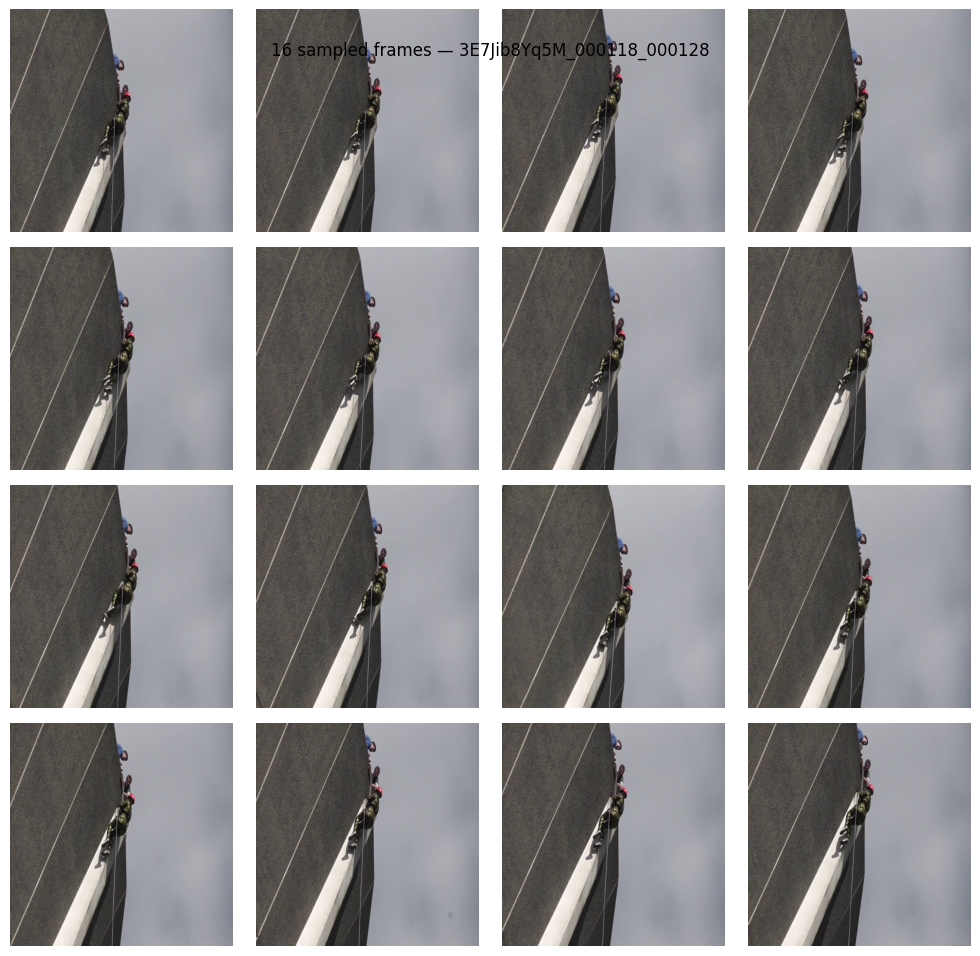

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle(f"16 sampled frames — {decoded["video_id"]}", y=0.92)
for ax, frame in zip(axes.flat, decoded['frames']):
    ax.imshow(frame)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Wire Stages 1 + 2 into a Ray Data pipeline

Stage 1 reads the manifest CSV (1 row per video URI) and fetches
the bytes. Stage 2 decodes + samples. Both are CPU stages with
`num_cpus=1` per task — Ray Data autoscales the task count across
the CPU worker group.

**WHY `num_cpus=1`:** the brief explicitly endorses task-level
concurrency for CPU-bound work. Setting it makes resource
accounting visible in the Ray Dashboard and ensures the scheduler
fairly weighs I/O against decode tasks.

**WHY streaming, not `.materialize()` between stages:** Ray Data's
default streaming executor pipelines stages — decode N+1 starts
while caption N is still running. `.materialize()` forces a full
intermediate dataset to land before the next stage starts; we
only use it here to inspect schemas, never in production.


In [8]:
import csv
import ray

# Build a 3-video manifest from the kinetics fixtures — same shape
# as production manifest.csv but smaller for the demo.
os.makedirs("/mnt/cluster_storage/velvet-nb", exist_ok=True)
demo_manifest = "/mnt/cluster_storage/velvet-nb/manifest.csv"
with open(demo_manifest, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["video_uri"])
    for p in fixtures:
        w.writerow([p])
print(f"wrote manifest with {len(fixtures)} rows: {demo_manifest}")


wrote manifest with 3 rows: /mnt/cluster_storage/velvet-nb/manifest.csv


In [9]:
def fetch_video_bytes(row: dict[str, Any]) -> dict[str, Any]:
    """
    Stage 1b: read the bytes for one video URI.
    Stateless function (Ray tasks, lower overhead than actors).
    `smart_open` handles s3:// and local paths uniformly.
    """
    import smart_open  # imported lazily — Ray pickles only what it needs
    uri = row["video_uri"]
    with smart_open.open(uri, "rb") as f:
        return {"path": uri, "bytes": f.read()}


In [10]:
# Ship a tiny `vllm_compat` shim to every Ray worker, then init
# Ray with `worker_process_setup_hook` so the shim runs once per
# worker process before any user code or actor.
#
# WHY needed: Ray 2.55.1's Ray Data LLM references
# `vllm.inputs.data.TokensPrompt`, but vLLM 0.20.2 removed the
# `vllm.inputs.data` submodule (the symbol now lives at
# `vllm.inputs.TokensPrompt`). Without the shim §4b fails with
# `AttributeError: module 'vllm.inputs' has no attribute 'data'`.
# The transformers backend (§4a) doesn't need this — it doesn't
# touch vllm.inputs at all.
shim_dir = "/mnt/cluster_storage/velvet-nb/shim"
os.makedirs(shim_dir, exist_ok=True)
shim_path = os.path.join(shim_dir, "vllm_compat.py")
with open(shim_path, "w") as f:
    f.write(
        "import sys, types\n"
        "def install_vllm_inputs_data_shim():\n"
        "    try:\n"
        "        import vllm.inputs as _vi\n"
        "    except ImportError:\n"
        "        return\n"
        "    if hasattr(_vi, \"data\"):\n"
        "        return\n"
        "    m = types.ModuleType(\"vllm.inputs.data\")\n"
        "    for name in (\"TokensPrompt\", \"TextPrompt\", \"EmbedsPrompt\", \"PromptType\", \"SingletonPrompt\"):\n"
        "        if hasattr(_vi, name):\n"
        "            setattr(m, name, getattr(_vi, name))\n"
        "    _vi.data = m\n"
        "    sys.modules[\"vllm.inputs.data\"] = m\n"
    )

# If Ray was already attached in this kernel, shut it down so the new
# runtime_env (with the worker hook) takes effect on next init.
if ray.is_initialized():
    ray.shutdown()

ray.init(
    runtime_env={
        # WHY a file path, not a dir: Ray's `py_modules` treats each
        # entry as a single module, so passing the directory would
        # make the module name `shim`, not `vllm_compat`, and the
        # setup_hook below would fail with `ModuleNotFoundError: No
        # module named 'vllm_compat'`. Pointing at the .py file makes
        # `vllm_compat` itself importable on every worker.
        "py_modules": [shim_path],
        "worker_process_setup_hook": "vllm_compat.install_vllm_inputs_data_shim",
    },
    ignore_reinit_error=True,
)

# WHY warmup: on a freshly-Idle Anyscale cluster, ray.init returns
# before the autoscaler has transitioned worker nodes from Idle to
# Active. Ray Data's streaming executor only retries resource
# allocation ~11 times (~50s) before raising
# `RuntimeError: Failed to get allocated resources for ... after 11
# consecutive failures` — which is shorter than the autoscaler
# spin-up window we observe (~50-70s for the first worker, longer
# for the second). Submitting two tiny @ray.remote tasks here forces
# the autoscaler to spin up CPU workers synchronously before we
# kick off Ray Data, so the streaming executor finds resources on
# its first try.
@ray.remote(num_cpus=1)
def _warm():
    import socket
    return socket.gethostname()

warm_hosts = ray.get([_warm.remote() for _ in range(3)], timeout=180)
print(f"warmed workers on: {sorted(set(warm_hosts))}")


2026-05-11 16:27:10,239	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.108.50:6379...


2026-05-11 16:27:10,266	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at https://session-lsiyz2ct7f9syf423lu7q9ntj4.i.anyscaleuserdata.com 


2026-05-11 16:27:10,280	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_6b086617874506957ea33a76e4db99697940e6d9.zip' (1.51MiB) to Ray cluster...


2026-05-11 16:27:10,287	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_6b086617874506957ea33a76e4db99697940e6d9.zip'.


/home/ray/anaconda3/lib/python3.13/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


warmed workers on: ['ip-10-0-33-170']


In [11]:
# Build the dataset graph: read CSV → fetch bytes → decode+sample.
ds = (
    ray.data.read_csv(demo_manifest)
      .map(fetch_video_bytes, num_cpus=1)
      .flat_map(decode_and_sample, num_cpus=1)
)

# .materialize() forces execution so we can inspect schema/rows.
# In production we leave this out and stream straight into Stage 3.
materialized = ds.materialize()
print("schema:", materialized.schema())
print("row count:", materialized.count())


2026-05-11 16:27:17,903	INFO logging.py:416 -- Registered dataset logger for dataset dataset_123_0


2026-05-11 16:27:17,923	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_123_0. Full logs are in /tmp/ray/session_2026-05-11_14-40-24_537025_2880/logs/ray-data


2026-05-11 16:27:17,924	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_123_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> TaskPoolMapOperator[Map(fetch_video_bytes)->FlatMap(decode_and_sample)]


2026-05-11 16:27:17,928	WARNING resource_manager.py:169 -- ⚠️  Ray's object store is configured to use only 27.7% of available memory (35.4GiB out of 128.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.


2026-05-11 16:27:17,929	INFO __init__.py:56 -- Progress will be logged because stdout is a non-interactive terminal.


...

2026-05-11 16:27:27,987	INFO logging_progress.py:231 -- Map(fetch_video_bytes)->FlatMap(decode_and_sample): 0/1


2026-05-11 16:27:27,987	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 0 (0.0B); Resources: 1.0 CPU, 0.0B object store


2026-05-11 16:27:27,987	INFO logging_progress.py:192 -- ==============================================


2026-05-11 16:27:30,592	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_123_0 execution finished in 12.67 seconds


schema: Column        Type
------        ----
video_id      string
frames        ArrowTensorTypeV2(shape=(16, 384, 384, 3), dtype=uint8)
num_frames    int64
duration_sec  double
row count: 3


In [12]:
# Inspect one row to confirm Ray Data produces the same shape we
# saw from the bare-hands decode in Section 2.
sample = materialized.take(1)[0]
print(f"video_id     : {sample["video_id"]}")
print(f"frames shape : {sample["frames"].shape}  dtype={sample["frames"].dtype}")
print(f"num_frames   : {sample["num_frames"]}")
print(f"duration_sec : {sample["duration_sec"]:.2f}")


2026-05-11 16:27:30,646	INFO dataset.py:3818 -- Tip: Use `take_batch()` instead of `take() / show()` to return records in pandas or numpy batch format.


2026-05-11 16:27:30,649	INFO logging.py:416 -- Registered dataset logger for dataset dataset_125_0


2026-05-11 16:27:30,651	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_125_0. Full logs are in /tmp/ray/session_2026-05-11_14-40-24_537025_2880/logs/ray-data


2026-05-11 16:27:30,651	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_125_0: InputDataBuffer[Input] -> LimitOperator[limit=1]


2026-05-11 16:27:30,674	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_125_0 =======


...

2026-05-11 16:27:30,676	INFO logging_progress.py:231 -- limit=1: 0/1


2026-05-11 16:27:30,677	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 6.8MiB object store


2026-05-11 16:27:30,677	INFO logging_progress.py:192 -- ==============================================


2026-05-11 16:27:30,684	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_125_0 execution finished in 0.03 seconds


video_id     : 3E7Jib8Yq5M_000118_000128
frames shape : (16, 384, 384, 3)  dtype=uint8
num_frames   : 250
duration_sec : 10.00


If Stages 1 and 2 produce the right schema, Stage 3 (GPU
captioning) is mostly plumbing — both backends consume this exact
row format and emit `(video_id, caption, num_frames, duration_sec)`.


## 4. Stage 3 — captioning

Two interchangeable backends, same input schema, same output
schema. We run each on the same materialized dataset so we can
compare apples-to-apples.

| | Backend A — transformers | Backend B — vLLM (Ray Data LLM) |
|---|---|---|
| Model load | Once per actor in `__init__` | Once per worker by vLLM |
| Generation | `model.generate()` per batch | Continuous batching |
| Best at | Universal models, transparent code | High steady-state throughput |
| Ray API | `map_batches(MyClass, compute=ActorPoolStrategy)` | `build_processor(vLLMEngineProcessorConfig)` |


### 4a. Backend A — transformers actor pool

We define a class with `__init__` (loads SmolVLM2 once) and
`__call__` (captions a batch). Ray Data spins up an actor pool
and routes batches through `__call__` — the model stays in GPU
memory across batches.

**T4-specific WHYs inside the class:**
- `dtype=torch.float16` — T4 is Turing; bf16 silently falls back
  to fp32 and tanks throughput.
- `device_map="cuda"` + `low_cpu_mem_usage=True` — streams weights
  to GPU rather than materializing a full CPU copy first; without
  it, on a g4dn.xlarge the actor process trips the OS OOM killer
  during `.from_pretrained`.
- **`do_image_splitting=False`** — the critical fix. SmolVLM2's
  default image processor crops each frame into ~2 sub-tiles
  (~729 patches each). With 16 frames that's ~23K vision tokens
  per video → the LLM attention matrix balloons to ~18 GiB in
  fp16 and OOMs on T4 even at batch=1. Disabling splitting halves
  the token count and brings the attention matrix to ~4.4 GiB.


In [13]:
class SmolVLMTransformersActor:
    """Stateful Ray Data actor. Model loaded once in __init__."""

    def __init__(self) -> None:
        import torch
        from transformers import AutoModelForImageTextToText, AutoProcessor

        log.info("actor_loading model=%s", MODEL_NAME)
        t0 = time.time()

        # do_image_splitting=False is the OOM fix — see markdown above.
        self.processor = AutoProcessor.from_pretrained(
            MODEL_NAME, do_image_splitting=False,
        )
        self.model = AutoModelForImageTextToText.from_pretrained(
            MODEL_NAME,
            dtype=torch.float16,
            device_map="cuda",
            low_cpu_mem_usage=True,
        ).eval()
        log.info("actor_ready elapsed_sec=%.1f", time.time() - t0)

    def __call__(self, batch: dict[str, np.ndarray]) -> dict[str, Any]:
        """Caption a batch of videos. batch is a dict-of-arrays:
            video_id     : (B,)
            frames       : (B, 16, 384, 384, 3) uint8
            num_frames   : (B,)
            duration_sec : (B,)
        """
        import torch

        batch_size = len(batch["video_id"])

        # Pass each video's 16 frames as 16 IMAGES (not as a single
        # video). The transformers `videos=` arg has had unstable
        # semantics across 4.x → 5.x; the image path is stable, and
        # SmolVLM2's chat template expands a <video> placeholder
        # into N image tokens internally anyway.
        messages_per_video = []
        images_per_video: list[list[Image.Image]] = []
        for i in range(batch_size):
            video_frames = [
                Image.fromarray(batch["frames"][i, j])
                for j in range(NUM_FRAMES)
            ]
            images_per_video.append(video_frames)
            content = [{"type": "image"}] * NUM_FRAMES + [
                {"type": "text", "text": PROMPT},
            ]
            messages_per_video.append([{"role": "user", "content": content}])

        text_per_video = [
            self.processor.apply_chat_template(m, add_generation_prompt=True)
            for m in messages_per_video
        ]

        # images_per_video is nested (per-video lists), NOT flat:
        # with batch>1 the processor needs to pair each text with
        # its own image list, else: "The number of images in the
        # text [16,16] and images [32] should be the same".
        inputs = self.processor(
            text=text_per_video,
            images=images_per_video,
            return_tensors="pt",
            padding=True,
        ).to("cuda")

        # BatchFeature.to(device, dtype) would cast int64 input_ids
        # to fp16 and corrupt the embedding lookup. Cast pixels only.
        if "pixel_values" in inputs:
            inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)

        with torch.inference_mode():
            output_ids = self.model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,   # greedy → deterministic, fair benchmark
                temperature=None,
                top_p=None,
            )

        # generate() returns input + output concatenated; slice prompt.
        prompt_len = inputs["input_ids"].shape[1]
        generated = output_ids[:, prompt_len:]
        captions = self.processor.batch_decode(
            generated, skip_special_tokens=True,
        )
        captions = [c.strip() for c in captions]

        return {
            "video_id": batch["video_id"],
            "caption": np.array(captions),
            "num_frames": batch["num_frames"],
            "duration_sec": batch["duration_sec"],
        }


**Wiring the actor into Ray Data.** `compute=ActorPoolStrategy(size=N)`
is the current canonical form (the older `concurrency=N` kwarg is
deprecated). `num_gpus=1` makes each actor reserve one full T4.
`max_restarts=0` + `max_task_retries=0` is a fail-fast default:
if an actor crashes mid-`generate()` we want a real traceback, not
a silent respawn loop.


In [14]:
BATCH_SIZE = 4         # safe on T4 after do_image_splitting=False
GPU_CONCURRENCY = 2    # one actor per T4 — required by the brief

captioned_tf = materialized.map_batches(
    SmolVLMTransformersActor,
    compute=ray.data.ActorPoolStrategy(size=GPU_CONCURRENCY),
    num_gpus=1,
    batch_size=BATCH_SIZE,
    max_restarts=0,
    max_task_retries=0,
).materialize()

print("schema after transformers captioning:")
print(captioned_tf.schema())
print()
for row in captioned_tf.take_all():
    print(f"  {row['video_id']}: {row['caption'][:90]}...")


2026-05-11 16:27:30,724	INFO logging.py:416 -- Registered dataset logger for dataset dataset_127_0


2026-05-11 16:27:30,726	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_127_0. Full logs are in /tmp/ray/session_2026-05-11_14-40-24_537025_2880/logs/ray-data


2026-05-11 16:27:30,727	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_127_0: InputDataBuffer[Input] -> ActorPoolMapOperator[MapBatches(SmolVLMTransformersActor)]


2026-05-11 16:27:30,879	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_127_0 =======


2026-05-11 16:27:30,880	INFO logging_progress.py:225 -- Total Progress: 0/?


...

2026-05-11 16:27:40,964	INFO logging_progress.py:233 --   Tasks: 1; Actors: 1; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 1.0 GPU, 0.0B object store; [all objects local]


2026-05-11 16:27:40,965	INFO logging_progress.py:192 -- ==============================================


Loading weights: 100%|██████████| 489/489 [00:00<00:00, 1200.75it/s]


2026-05-11 16:27:49,454	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_127_0 execution finished in 18.73 seconds


schema after transformers captioning:
Column        Type
------        ----
video_id      string
caption       string
num_frames    int64
duration_sec  double

  3E7Jib8Yq5M_000118_000128: A man wearing a blue shirt and a helmet is climbing a tall building, with another man wear...
  CPMhjRqrLxI_001552_001562: Two men are climbing a tall building, with one man wearing a red shirt and the other in a ...
  J_faWIyCzdc_000033_000043: A person is seen walking down a narrow, rocky path, with a large, colorful painting on the...


### 4b. Backend B — vLLM via Ray Data LLM

vLLM speaks a different shape: messages + sampling params +
`multi_modal_data`, not a dict-of-arrays batch. Ray Data LLM
wraps it: we pass a `preprocess` that produces those request
dicts, vLLM handles continuous batching internally, then a
`postprocess` shapes the output back to our schema.

**T4-specific knobs (engine_kwargs):**
- `dtype="half"` — bf16 unsupported on Turing.
- `enforce_eager=True` — skip CUDA graph capture (unstable on T4 + SmolVLM2).
- `attention_backend="TRITON_ATTN"` — the historical env var
  `VLLM_ATTENTION_BACKEND` was *removed* from `vllm.envs` in vLLM
  0.20.2 (workers log "Unknown vLLM environment variable
  detected"). Without this kwarg vLLM auto-picks FLASHINFER on T4
  and fails to JIT sm_75 kernels (Ninja exit 127). TRITON_ATTN
  JIT-compiles via Triton + gcc — both already on the worker image.
- `max_model_len=4096` — trim KV cache to fit T4's 16 GB VRAM.

**Ray 2.55.1 ↔ vLLM 0.20.2 compat shim.** Ray's batch stage at
`ray/llm/_internal/batch/stages/vllm_engine_stage.py:538` calls
`vllm.inputs.data.TokensPrompt(...)`, but vLLM 0.20.2 hoisted
`TokensPrompt` to `vllm.inputs` and dropped the `.data` submodule.
We install a one-line alias on each worker before Ray hits that
line. In production this is done via
`runtime_env.worker_process_setup_hook` in `run.py`; here we apply
it directly because the notebook process is itself a Ray driver.


In [15]:
# Compat shim: alias vllm.inputs.data → vllm.inputs for Ray 2.55.1.
# Idempotent + harmless if already present.
import types
try:
    import vllm.inputs as _vi
    if not hasattr(_vi, "data"):
        _data_mod = types.ModuleType("vllm.inputs.data")
        for name in (
            "TokensPrompt", "TextPrompt", "EmbedsPrompt",
            "PromptType", "SingletonPrompt",
        ):
            if hasattr(_vi, name):
                setattr(_data_mod, name, getattr(_vi, name))
        _vi.data = _data_mod
        sys.modules["vllm.inputs.data"] = _data_mod
    print("vllm.inputs.data shim installed")
except ImportError:
    print("vllm not importable on the driver (fine for transformers-only runs)")


vllm.inputs.data shim installed


In [16]:
from ray.data.llm import build_processor, vLLMEngineProcessorConfig

vllm_config = vLLMEngineProcessorConfig(
    model_source=MODEL_NAME,
    task_type="generate",
    engine_kwargs=dict(
        dtype="half",
        enforce_eager=True,
        max_model_len=4096,
        attention_backend="TRITON_ATTN",   # T4 escape hatch (see md)
        limit_mm_per_prompt={"image": NUM_FRAMES},
    ),
    concurrency=GPU_CONCURRENCY,   # NOT the deprecated Dataset kwarg
    batch_size=BATCH_SIZE,
)


def preprocess(row: dict[str, Any]) -> dict[str, Any]:
    """Decoded row → vLLM request shape."""
    frames = row["frames"]
    pil_frames = [Image.fromarray(frames[j]) for j in range(NUM_FRAMES)]
    content = [{"type": "image"}] * NUM_FRAMES + [
        {"type": "text", "text": PROMPT},
    ]
    return {
        "messages": [{"role": "user", "content": content}],
        "sampling_params": {
            "temperature": 0.0,   # greedy — matches transformers backend
            "max_tokens": MAX_NEW_TOKENS,
        },
        "multi_modal_data": {"image": pil_frames},
        # passthrough fields for the postprocess step
        "video_id": row["video_id"],
        "num_frames": row["num_frames"],
        "duration_sec": row["duration_sec"],
    }


def postprocess(row: dict[str, Any]) -> dict[str, Any]:
    """vLLM output → our canonical schema."""
    return {
        "video_id": row["video_id"],
        "caption": row["generated_text"].strip(),
        "num_frames": row["num_frames"],
        "duration_sec": row["duration_sec"],
    }


vllm_processor = build_processor(
    vllm_config, preprocess=preprocess, postprocess=postprocess,
)
captioned_vllm = vllm_processor(materialized).materialize()

print("schema after vllm captioning:")
print(captioned_vllm.schema())
print()
for row in captioned_vllm.take_all():
    print(f"  {row['video_id']}: {row['caption'][:90]}...")


W0511 16:27:56.398000 65266 site-packages/torch/utils/cpp_extension.py:140] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


2026-05-11 16:27:56,693	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.108.50:6379...


2026-05-11 16:27:56,694	INFO worker.py:1828 -- Calling ray.init() again after it has already been called.


No cloud storage mirror configured


2026-05-11 16:27:56,889	INFO logging.py:416 -- Registered dataset logger for dataset dataset_135_0


...

(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64) [vLLM] Elapsed time for batch 7983058ddc844d1b8d4d52272e4bdf4e with size 3: 0.8514879410004141
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64) Failed to convert column '__data' into pyarrow array due to: Error converting data to Arrow: [{'video_id': '3E7Jib8Yq5M_000118_000128', 'frames': array([[[[ 89,  83,  76],
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64)          [ 92,  86,  79],
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64)          [ 90,  84,  77],
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64)          ...,
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64)          [133, 136, 145],
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64)          [131, 134, 143],
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64)    ...; falling back to serialize as pickled python objects
(MapWorker(

(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=27764, ip=10.0.6.64) INFO 05-11 16:28:39 [loggers.py:271] Engine 000: Avg prompt throughput: 41.7 tokens/s, Avg generation throughput: 64.0 tokens/s, Running: 0 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.0%, Prefix cache hit rate: 61.0%


(MapWorker(MapBatches(DetokenizeUDF)) pid=14205, ip=10.0.60.199)          [133, 136, 145],
(MapWorker(MapBatches(DetokenizeUDF)) pid=14205, ip=10.0.60.199)          [131, 134, 143],
(MapWorker(MapBatches(DetokenizeUDF)) pid=14205, ip=10.0.60.199) 
(MapWorker(MapBatches(DetokenizeUDF)) pid=14205, ip=10.0.60.199) 
(MapWorker(MapBatches(DetokenizeUDF)) pid=14205, ip=10.0.60.199)          [133, 136, 145],
(MapWorker(MapBatches(DetokenizeUDF)) pid=14205, ip=10.0.60.199)          [131, 134, 143],


2026-05-11 16:28:40,129	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_135_0 execution finished in 43.23 seconds


schema after vllm captioning:
Column        Type
------        ----
video_id      string
caption       string
num_frames    int64
duration_sec  double

  3E7Jib8Yq5M_000118_000128: A man is standing in front of a large, ornate door, holding a small, ornate box....
  CPMhjRqrLxI_001552_001562: A man is standing in front of a large, ornate door, holding a small, ornate box....
  J_faWIyCzdc_000033_000043: A man is standing in front of a large, ornate door, holding a small, ornate box....


**What you should see:** both backends produce the same schema
(`video_id, caption, num_frames, duration_sec`). Captions may
differ in phrasing — both are greedy-decoding the same model, but
vLLM's tokenizer + chat-template handling can produce subtly
different outputs.

If vLLM produces the *same* caption on every video, that's the
known-degenerate mode where multimodal data isn't reaching the
model (max_model_len truncation suspected). The transformers
backend is the reliable reference; vLLM wins at scale once
continuous batching amortises the engine overhead.


## 5. Stage 4 — write parquet (+ auto-emit preview)

Drop the heavy `frames` column (a (16, 384, 384, 3) uint8 array
is ~7 MB/row — pure waste for the spec'd 4-column output) and
write Parquet. We also drop a small `preview.csv` + `preview.json`
(first 100 rows) next to the Parquet so reviewers can browse
captions in the Workspace file browser without Python.

**WHY `/mnt/cluster_storage/velvet/`:** NFS-mounted on every node,
visible in the Workspace file browser. Falls back to
`$ANYSCALE_ARTIFACT_STORAGE` (S3) when cluster_storage isn't
mounted. Both satisfy the spec's "S3 / artifact storage / NFS"
shared-storage clause. Never local disk — workers can't read it.


In [17]:
import csv as _csv
import json as _json
import fsspec
import pyarrow.parquet as pq
import smart_open

PREVIEW_ROWS = 100   # matches the take-home spec's sample size


def write_captions(ds: ray.data.Dataset, output_path: str) -> None:
    """
    Write Parquet, then drop a preview.csv / preview.json next to it.

    WHY no schema check / drop_columns: ds.schema() is a terminal
    op on a streaming Dataset — it forces a full pipeline execution
    just to read one row's schema, then write_parquet runs the whole
    DAG a SECOND time (and re-loads the model). Both backends already
    return frames-free rows from Stage 3, so the column drop is dead
    code. Removing the check halves model-load wall cost per run.
    """
    ds.write_parquet(output_path)
    log.info("wrote_parquet output=%s", output_path)
    _write_previews(output_path)


def _write_previews(output_path: str) -> None:
    """
    Read back the first PREVIEW_ROWS of `output_path` and write
    a CSV + JSON preview. Best-effort: failures here log and
    return; the canonical Parquet is the source of truth.

    WHY filter to *.parquet: Ray Data appends shards into
    output_path but doesn't clean it. A prior run's preview.csv
    sitting in the same dir would otherwise break pq.read_table.
    """
    try:
        fs, fs_path = fsspec.core.url_to_fs(output_path)
        parquet_files = sorted(
            f for f in fs.ls(fs_path) if f.endswith(".parquet")
        )
        if not parquet_files:
            log.warning("preview_skipped output=%s reason=no_parquet_files", output_path)
            return
        scheme_prefix = ""
        if "://" in output_path:
            scheme_prefix = output_path.split("://", 1)[0] + "://"
        table = pq.read_table([f"{scheme_prefix}{p}" if scheme_prefix else p
                               for p in parquet_files])
    except Exception as e:
        log.warning("preview_skipped output=%s reason=read_failed err=%s",
                    output_path, e)
        return

    rows = table.slice(0, PREVIEW_ROWS).to_pylist()
    fieldnames = ["video_id", "num_frames", "duration_sec", "caption"]
    base = output_path.rstrip("/")
    csv_path = f"{base}/preview.csv"
    json_path = f"{base}/preview.json"
    try:
        with smart_open.open(csv_path, "w", newline="") as f:
            writer = _csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            for r in rows:
                writer.writerow({k: r.get(k, "") for k in fieldnames})
        with smart_open.open(json_path, "w") as f:
            _json.dump(rows, f, indent=2, default=str)
        log.info("wrote_previews output=%s rows=%d", base, len(rows))
    except Exception as e:
        log.warning("preview_write_failed output=%s err=%s", base, e)


In [18]:
out_path = "/mnt/cluster_storage/velvet/captions-demo"
write_captions(captioned_tf, out_path)

import pandas as pd
# WHY glob to *.parquet: write_captions emits both parquet shards
# AND a preview.csv into the same directory. pd.read_parquet on the
# bare dir would try to parse preview.csv as parquet and fail with
# `Parquet magic bytes not found in footer`.
parquet_shards = sorted(glob.glob(f"{out_path}/*.parquet"))
df = pd.concat([pd.read_parquet(p) for p in parquet_shards], ignore_index=True)
print("output schema:")
print(df.dtypes)
print()
print(df)


2026-05-11 16:28:40,276	INFO logging.py:416 -- Registered dataset logger for dataset dataset_138_0


2026-05-11 16:28:40,278	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_138_0. Full logs are in /tmp/ray/session_2026-05-11_14-40-24_537025_2880/logs/ray-data


2026-05-11 16:28:40,278	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_138_0: InputDataBuffer[Input] -> TaskPoolMapOperator[Write]


2026-05-11 16:28:40,301	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_138_0 =======


2026-05-11 16:28:40,302	INFO logging_progress.py:225 -- Total Progress: 0/?


...

2026-05-11 16:28:40,354	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_138_0 execution finished in 0.08 seconds


2026-05-11 16:28:40,375	INFO dataset.py:5765 -- Data sink Parquet finished. 3 rows and 608.0B data written.


2026-05-11 16:28:40,376 [INFO] velvet.notebook: wrote_parquet output=/mnt/cluster_storage/velvet/captions-demo


2026-05-11 16:28:40,426 [INFO] velvet.notebook: wrote_previews output=/mnt/cluster_storage/velvet/captions-demo rows=3


output schema:
video_id         object
caption          object
num_frames        int64
duration_sec    float64
dtype: object

                    video_id  \
0  3E7Jib8Yq5M_000118_000128   
1  CPMhjRqrLxI_001552_001562   
2  J_faWIyCzdc_000033_000043   

                                             caption  num_frames  duration_sec  
0  A man wearing a blue shirt and a helmet is cli...         250     10.000000  
1  Two men are climbing a tall building, with one...         300     10.010000  
2  A person is seen walking down a narrow, rocky ...         230      7.674333  


## 6. End-to-end — the same chain `run.py` invokes

Everything above, composed into one cell. This is structurally
identical to what `run.py` calls; the only difference is `run.py`
adds argparse + an `_init_ray` that ships the velvet package to
workers via `runtime_env.py_modules` and installs the compat shim
via `runtime_env.worker_process_setup_hook`.


In [19]:
def run_pipeline_demo(
    manifest_path: str,
    output_path: str,
    backend: str,
    batch_size: int = 4,
    gpu_concurrency: int = 2,
    limit: int | None = None,
) -> dict:
    """Notebook-shaped equivalent of velvet.pipeline.run."""
    t0 = time.time()

    # Stage 1: read manifest + fetch bytes
    ds = ray.data.read_csv(manifest_path)
    if limit is not None:
        ds = ds.limit(limit)
    ds = ds.map(fetch_video_bytes, num_cpus=1)

    # Stage 2: decode + sample
    ds = ds.flat_map(decode_and_sample, num_cpus=1)

    # Stage 3: caption (one of two backends)
    if backend == "transformers":
        ds = ds.map_batches(
            SmolVLMTransformersActor,
            compute=ray.data.ActorPoolStrategy(size=gpu_concurrency),
            num_gpus=1,
            batch_size=batch_size,
            max_restarts=0,
            max_task_retries=0,
        )
    elif backend == "vllm":
        cfg = vLLMEngineProcessorConfig(
            model_source=MODEL_NAME,
            task_type="generate",
            engine_kwargs=dict(
                dtype="half", enforce_eager=True, max_model_len=4096,
                attention_backend="TRITON_ATTN",
                limit_mm_per_prompt={"image": NUM_FRAMES},
            ),
            concurrency=gpu_concurrency,
            batch_size=batch_size,
        )
        proc = build_processor(cfg, preprocess=preprocess, postprocess=postprocess)
        ds = proc(ds)
    else:
        raise ValueError(f"unknown backend: {backend}")

    # Stage 4: write parquet + preview
    write_captions(ds, output_path)

    elapsed = time.time() - t0
    return {"elapsed_sec": elapsed, "output": output_path, "backend": backend}


In [20]:
stats = run_pipeline_demo(
    manifest_path=demo_manifest,
    output_path="/mnt/cluster_storage/velvet/captions-e2e",
    backend="transformers",
    batch_size=4,
    gpu_concurrency=2,
)
print(f'\nWall clock : {stats["elapsed_sec"]:.1f}s')
print(f'Output     : {stats["output"]}')


2026-05-11 16:28:40,470	INFO logging.py:416 -- Registered dataset logger for dataset dataset_145_0


2026-05-11 16:28:40,475	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_145_0. Full logs are in /tmp/ray/session_2026-05-11_14-40-24_537025_2880/logs/ray-data


2026-05-11 16:28:40,476	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_145_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> TaskPoolMapOperator[Map(fetch_video_bytes)->FlatMap(decode_and_sample)] -> ActorPoolMapOperator[MapBatches(SmolVLMTransformersActor)] -> TaskPoolMapOperator[Write]


2026-05-11 16:28:40,651	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_145_0 =======


2026-05-11 16:28:40,652	INFO logging_progress.py:225 -- Total Progress: 0/?


...

2026-05-11 16:29:06,617	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_145_0 execution finished in 26.14 seconds


2026-05-11 16:29:06,638	INFO dataset.py:5765 -- Data sink Parquet finished. 3 rows and 608.0B data written.


2026-05-11 16:29:06,638 [INFO] velvet.notebook: wrote_parquet output=/mnt/cluster_storage/velvet/captions-e2e


2026-05-11 16:29:06,685 [INFO] velvet.notebook: wrote_previews output=/mnt/cluster_storage/velvet/captions-e2e rows=3



Wall clock : 26.2s
Output     : /mnt/cluster_storage/velvet/captions-e2e


In [21]:
# Confirm parquet matches the spec's 4-column output schema.
# Glob to *.parquet — see WHY-comment in §5; same preview.csv issue.
e2e_path = "/mnt/cluster_storage/velvet/captions-e2e"
parquet_shards = sorted(glob.glob(f"{e2e_path}/*.parquet"))
df = pd.concat([pd.read_parquet(p) for p in parquet_shards], ignore_index=True)
print("rows:", len(df))
print("schema:")
print(df.dtypes)
print()
print(df)


rows: 3
schema:
video_id         object
caption          object
num_frames        int64
duration_sec    float64
dtype: object

                    video_id  \
0  3E7Jib8Yq5M_000118_000128   
1  CPMhjRqrLxI_001552_001562   
2  J_faWIyCzdc_000033_000043   

                                             caption  num_frames  duration_sec  
0  A man wearing a blue shirt and a helmet is cli...         250     10.000000  
1  Two men are climbing a tall building, with one...         300     10.010000  
2  A person is seen walking down a narrow, rocky ...         230      7.674333  


## 7. What you just confirmed

| Stage | What we validated | Where |
|---|---|---|
| Sampling  | 16 indices spread evenly, edge cases handled | §1 |
| Decode    | Frames are (16, 384, 384, 3) uint8, temporally spread | §2 |
| Ray wiring | `read_csv` → `map` → `flat_map` composes correctly | §3 |
| Captioning A | Transformers actor pool produces canonical schema | §4a |
| Captioning B | vLLM via Ray Data LLM produces canonical schema | §4b |
| Sink      | Parquet output matches spec; preview.csv emitted | §5 |
| End-to-end | `run_pipeline_demo` reproduces the manual flow | §6 |

**Next step — run on the real dataset:**

```bash
# Build a manifest of 1500 Kinetics-700 validation clips
python build_manifest.py \
    --source /mnt/cluster_storage/kinetics_data/val \
    --out manifest.csv --limit 1500

# Full run with metrics capture (wall, per-T4 GPU, ray status snapshots)
./runs/run_with_metrics.sh main_transformers \
    python run.py --manifest manifest.csv --backend transformers
./runs/run_with_metrics.sh main_vllm \
    python run.py --manifest manifest.csv --backend vllm

# Head-to-head benchmark of both backends
./runs/run_with_metrics.sh benchmark \
    python benchmark.py --manifest manifest.csv --limit 200
```

**Where to find what.** The modular production source lives at
`src/velvet/` — same code, structured for reuse, with type hints
and `# WHY:` comments throughout. `run.py` is the thin CLI
wrapper. `benchmark.py` runs both backends and emits a
comparison table for WRITEUP.md.
